<a href="https://colab.research.google.com/github/bryaanabraham/Digital_Image_Processing/blob/main/Logo_classification_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [9]:
img_width, img_height = 150, 150
batch_size = 32

train_data_dir = '/content/drive/MyDrive/DIP/train'
test_data_dir = '/content/drive/MyDrive/DIP/test'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary')

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=10,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size)

model.save('image_classifier_model.h5')

loss, accuracy = model.evaluate(validation_generator)

Found 659 images belonging to 2 classes.
Found 165 images belonging to 2 classes.
Epoch 1/10
20/20 [==============================] - 51s 2s/step - loss: 0.6393 - accuracy: 0.6656 - val_loss: 0.6149 - val_accuracy: 0.6562
Epoch 2/10
20/20 [==============================] - 45s 2s/step - loss: 0.5700 - accuracy: 0.6475 - val_loss: 0.5008 - val_accuracy: 0.7063
Epoch 3/10
20/20 [==============================] - 43s 2s/step - loss: 0.5104 - accuracy: 0.6746 - val_loss: 0.4734 - val_accuracy: 0.7125
Epoch 4/10
20/20 [==============================] - 42s 2s/step - loss: 0.5043 - accuracy: 0.6794 - val_loss: 0.4815 - val_accuracy: 0.7125
Epoch 5/10
20/20 [==============================] - 41s 2s/step - loss: 0.4836 - accuracy: 0.7097 - val_loss: 0.4855 - val_accuracy: 0.6812
Epoch 6/10
20/20 [==============================] - 39s 2s/step - loss: 0.4790 - accuracy: 0.7209 - val_loss: 0.4666 - val_accuracy: 0.7125
Epoch 7/10
20/20 [==============================] - 43s 2s/step - loss: 0.4695

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


6/6 [==============================] - 3s 399ms/step - loss: 0.3802 - accuracy: 0.8061


1/1 [==============================] - 0s 201ms/step
Image:


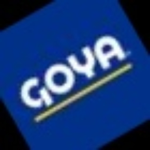

Prediction: Fake


In [12]:
model = tf.keras.models.load_model('image_classifier_model.h5')

testing_directory = '/content/drive/MyDrive/DIP/test'

fake_directory = os.path.join(testing_directory, 'Fake')
fake_image_files = os.listdir(fake_directory)

first_fake_image = fake_image_files[0]

image_path = os.path.join(fake_directory, first_fake_image)
img = Image.open(image_path)
img = img.resize((img_width, img_height))
img_array = np.expand_dims(np.array(img) / 255.0, axis=0)

prediction = model.predict(img_array)
predicted_class = "Fake" if prediction[0][0] < 0.5 else "Genuine"

print("Image:")
display(img)
print("Prediction:", predicted_class)
